### RaschPy PCM worked example

This notebook works through a sample Rasch analysis of a simulated data set (1,000 persons, 10 items - 4 with a maximum score of 5 and 6 with a maximum score of 3, and no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.PCM_Sim(no_of_items=10, no_of_persons=80, max_score_vector=[4] * 10, seed=108)
responses_disconnected = sim_disconnected.responses.copy()
responses_disconnected.iloc[:40, 5:] = float('nan')   # first 40 persons: only answer items 1-5
responses_disconnected.iloc[40:, :5] = float('nan')    # last 40 persons: only answer items 6-10

broken_pcm = rp.PCM(responses_disconnected, [4] * 10)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/pcm.py:223: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 5): ['Item_1', 'Item_2', 'Item_3', 'Item_4', 'Item_5']; Sub-group 2 (size 5): ['Item_6', 'Item_7', 'Item_8', 'Item_9', 'Item_10']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_32784/2303287120.py:6: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_pcm = rp.PCM(responses_disconnected, [4] * 10)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_pcm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4', 'Item_5'],
  ['Item_6', 'Item_7', 'Item_8', 'Item_9', 'Item_10']],
 'directionally_isolated_items': []}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=42` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set. 10 items, 1,000 persons, 20% missing data (so each person responds to ~8 items and each item has ~800 responses).

In [4]:
max_score_vector = [5, 5, 5, 5, 3, 3, 3, 3, 3, 3]
sim = rp.PCM_Sim(no_of_items=10, no_of_persons=1000, max_score_vector=max_score_vector, missing=0.2, seed=42)
sim.responses.to_csv('pcm_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_pcm()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_pcm('pcm_scores.csv', max_score_vector=max_score_vector)

Check the data - view the first two lines

In [6]:
data.head(2)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10
Person_1,1.0,2.0,4.0,NaN,3.0,3.0,1.0,1.0,0.0,NaN
Person_2,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0


Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10


Create a PCM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `pcm.generating`, which lets us check parameter recovery further down, and also means `max_score_vector` doesn't need to be supplied again. If you're analysing your own data, pass a DataFrame and `max_score_vector` instead (e.g. `rp.PCM(data, max_score_vector)`).

In [8]:
pcm = rp.PCM(sim)

Generate item estimates. The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
pcm.calibrate()

CPU times: user 4.07 ms, sys: 381 μs, total: 4.45 ms
Wall time: 4.26 ms


Check the central item location estimates - view the first two items

In [10]:
pcm.items.head(2)

Item_1    1.149410
Item_2   -0.351577
dtype: float64

Since this is simulated data, we know the true generating item locations (`pcm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')


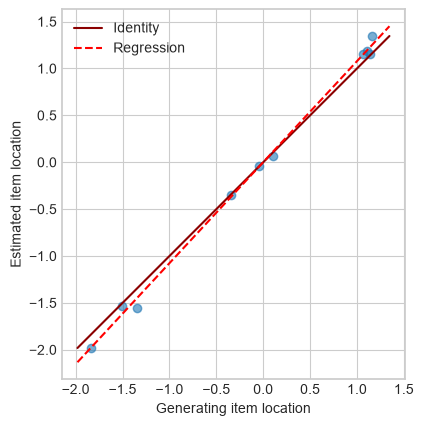

item location Pearson correlation:              0.999
item location SD ratio (estimated / generating): 1.078
item location regression coefficient:            1.077
item location RMSE:                              0.105


In [12]:
recovery_plot(pcm.generating.items, pcm.items, 'item location', 'my_pcm_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [13]:
%%time
pcm.item_stats_df(full=True)
pcm.item_stats.to_csv('pcm_item_stats.csv')

CPU times: user 3.73 s, sys: 22.8 ms, total: 3.75 s
Wall time: 3.75 s


Check the item statistics table

In [14]:
pcm.item_stats

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,1.149,0.065,1.040,1.301,794,0.356,0.871,-2.636,0.865,-2.480,0.808,0.784
Item_2,-0.352,0.044,-0.451,-0.276,786,0.557,0.855,-2.912,0.787,-3.730,0.835,0.811
Item_3,-0.039,0.048,-0.136,0.057,806,0.528,0.947,-1.031,0.949,-0.938,0.805,0.795
Item_4,0.067,0.053,-0.036,0.172,805,0.515,0.876,-2.555,0.865,-2.759,0.816,0.790
Item_5,-1.550,0.076,-1.704,-1.407,808,0.737,0.983,-0.291,1.060,0.658,0.700,0.691
Item_6,-1.529,0.072,-1.685,-1.403,793,0.745,0.965,-0.612,0.942,-0.621,0.695,0.681
Item_7,1.346,0.074,1.215,1.506,800,0.303,0.948,-1.005,0.932,-1.210,0.720,0.694
Item_8,1.181,0.067,1.061,1.328,803,0.302,0.948,-0.968,0.956,-0.623,0.724,0.705
Item_9,1.155,0.063,1.036,1.291,808,0.323,1.000,0.021,0.933,-0.972,0.723,0.717
Item_10,-1.981,0.100,-2.198,-1.817,808,0.794,0.968,-0.550,1.045,0.504,0.647,0.647


Generate a table of threshold statistics (and check run time), and save to file

In [15]:
%%time
pcm.threshold_stats_df(full=True)
pcm.threshold_stats.to_csv('pcm_threshold_stats_centred.csv')
pcm.threshold_stats_uncentred.to_csv('pcm_threshold_stats_uncentred.csv')

CPU times: user 3.74 ms, sys: 965 μs, total: 4.71 ms
Wall time: 4.25 ms


Check the centred threshold statistics table - view the first two thresholds

In [16]:
pcm.threshold_stats.head(2)

Estimate     SE   2.5%  97.5%  Infit MS  Infit Z  Outfit MS  \
Item_1 1    -2.128  0.118 -2.355 -1.892     0.940   -1.327      0.923   
       2    -1.116  0.131 -1.352 -0.853     0.975   -0.583      0.952   

          Outfit Z  Discrim  PM corr  Exp PM corr  
Item_1 1    -1.115    1.164    0.217        0.197  
       2    -0.746    1.101    0.142        0.132

Check the uncentred threshold statistics table - view the first two items

In [17]:
pcm.threshold_stats_uncentred.head(2)

Estimate     SE   2.5%  97.5%  Infit MS  Infit Z  Outfit MS  \
Item_1 1    -0.979  0.118 -1.206 -0.743     0.940   -1.327      0.923   
       2     0.033  0.131 -0.203  0.296     0.975   -0.583      0.952   

          Outfit Z  Discrim  PM corr  Exp PM corr  
Item_1 1    -1.115    1.164    0.217        0.197  
       2    -0.746    1.101    0.142        0.132

And the same recovery check for the uncentred threshold structure, against `pcm.generating.thresholds_uncentred`. Since thresholds are per-item, we flatten (item, threshold) pairs into a single series with `.unstack()` first:

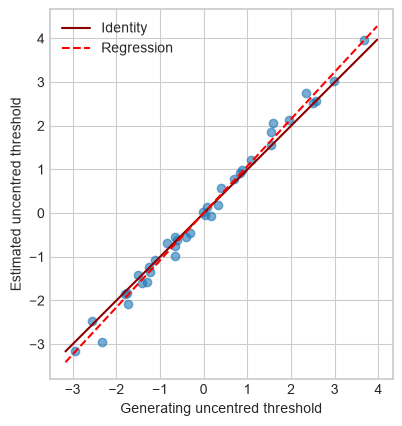

uncentred threshold Pearson correlation:              0.995
uncentred threshold SD ratio (estimated / generating): 1.083
uncentred threshold regression coefficient:            1.078
uncentred threshold RMSE:                              0.21


In [18]:
orig_thresholds = pcm.generating.thresholds_uncentred.unstack().dropna()
est_thresholds = pcm.thresholds_uncentred.unstack().dropna()
recovery_plot(orig_thresholds, est_thresholds, 'uncentred threshold', 'my_pcm_threshold_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [19]:
%%time
pcm.person_stats_df(full=True)
pcm.person_stats.to_csv('pcm_person_stats.csv')

CPU times: user 6.04 ms, sys: 649 μs, total: 6.69 ms
Wall time: 6.53 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [20]:
pcm.person_stats.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Infit Z,Outfit MS,Outfit Z
Person_1,0.071,0.425,0.354,15,30,0.500,0.692,-0.514,0.633,-0.685
Person_2,-2.618,0.534,0.365,4,38,0.105,0.468,-0.947,0.331,-0.989
Person_3,2.258,0.642,0.398,18,22,0.818,0.384,-1.100,0.270,-0.564
Person_4,1.532,0.495,0.651,22,30,0.733,1.725,1.265,4.408,2.977
Person_5,-3.191,0.703,0.675,2,33,0.061,0.922,0.133,0.681,0.010
Person_6,-2.203,0.589,0.259,3,27,0.111,0.194,-1.634,0.174,-1.396
Person_7,-0.337,0.395,0.325,17,35,0.486,0.677,-0.586,0.637,-0.751
Person_8,-0.248,0.766,0.534,6,11,0.545,0.486,-0.367,0.667,-0.173
Person_9,0.234,0.459,0.464,15,27,0.556,1.022,0.220,1.208,0.540
Person_10,-1.327,0.436,0.423,9,30,0.300,0.944,0.041,0.906,-0.027


And the same recovery check for person locations, against `pcm.generating.persons`:

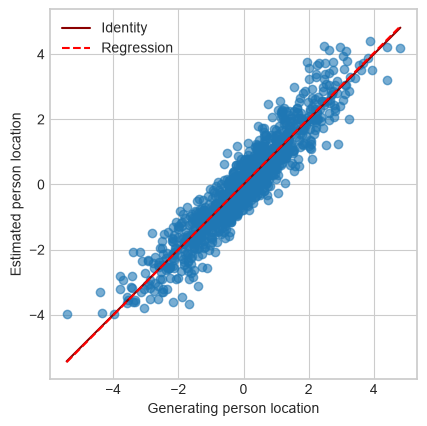

person location Pearson correlation:              0.941
person location SD ratio (estimated / generating): 1.07
person location regression coefficient:            1.007
person location RMSE:                              0.54


In [21]:
recovery_plot(pcm.generating.persons, pcm.persons, 'person location', 'my_pcm_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [22]:
%%time
pcm.test_stats_df()
pcm.test_stats.to_csv('pcm_test_stats.csv')

CPU times: user 760 μs, sys: 417 μs, total: 1.18 ms
Wall time: 992 μs


Check the test statistics table

In [23]:
pcm.test_stats

,Items,Thresholds,Persons
Mean,-0.055,0.000,0.011
SD,1.275,1.741,1.588
Separation ratio,18.768,10.737,3.168
Strata,25.357,14.649,4.557
Reliability,0.997,0.991,0.909


Run a residual correlation analysis (and check run time), and save relevant output to file

In [24]:
%%time
pcm.res_corr_analysis()
pcm.residual_correlations.to_csv('pcm_residual_correlations.csv')
pcm.loadings.to_csv('pcm_loadings.csv')

CPU times: user 5.47 ms, sys: 1.67 ms, total: 7.14 ms
Wall time: 7.82 ms


View the table of pairwise standard residual correlations

In [25]:
round(pcm.residual_correlations, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10
Item_1,1.000,-0.197,-0.190,-0.105,-0.131,-0.097,-0.168,-0.206,-0.143,-0.128
Item_2,-0.197,1.000,-0.191,-0.162,-0.179,-0.206,-0.106,-0.194,-0.152,-0.125
Item_3,-0.190,-0.191,1.000,-0.184,-0.212,-0.136,-0.131,-0.156,-0.177,-0.144
Item_4,-0.105,-0.162,-0.184,1.000,-0.151,-0.157,-0.162,-0.111,-0.214,-0.121
Item_5,-0.131,-0.179,-0.212,-0.151,1.000,-0.131,-0.024,-0.020,-0.096,-0.110
Item_6,-0.097,-0.206,-0.136,-0.157,-0.131,1.000,-0.096,-0.072,-0.026,-0.119
Item_7,-0.168,-0.106,-0.131,-0.162,-0.024,-0.096,1.000,-0.104,-0.136,-0.060
Item_8,-0.206,-0.194,-0.156,-0.111,-0.020,-0.072,-0.104,1.000,-0.112,-0.091
Item_9,-0.143,-0.152,-0.177,-0.214,-0.096,-0.026,-0.136,-0.112,1.000,-0.064
Item_10,-0.128,-0.125,-0.144,-0.121,-0.110,-0.119,-0.060,-0.091,-0.064,1.000


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [26]:
round(pcm.loadings['PC 1'], 3)

Item_1    -0.009
Item_2    -0.176
Item_3    -0.169
Item_4    -0.164
Item_5     0.191
Item_6     0.081
Item_7     0.044
Item_8     0.169
Item_9     0.193
Item_10    0.020
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the thresholds marked

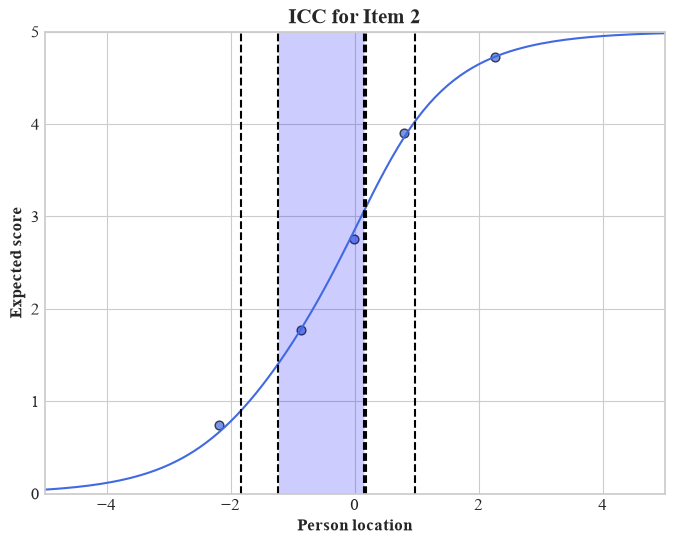

In [27]:
pcm.icc('Item_2', title='ICC for Item 2', obs=True, thresh_lines=True, cat_highlight=2, xmin=-5, xmax=5, filename='my_pcm_icc')

Produce category response curves for Item 2, with the central item location marked

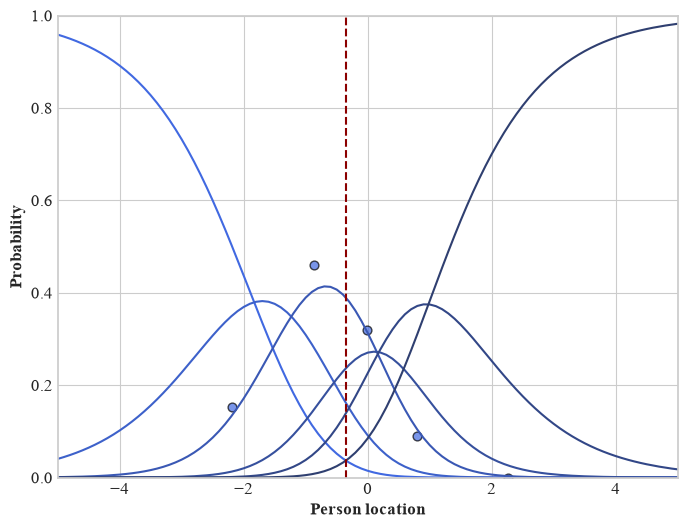

In [28]:
pcm.crcs('Item_2', central_location=True, obs=[2], xmin=-5, xmax=5, filename='my_pcm_crcs')

Produce threshold characteristic curves for Item 2, with observed category means plotted for threshold 2 and the central item location marked

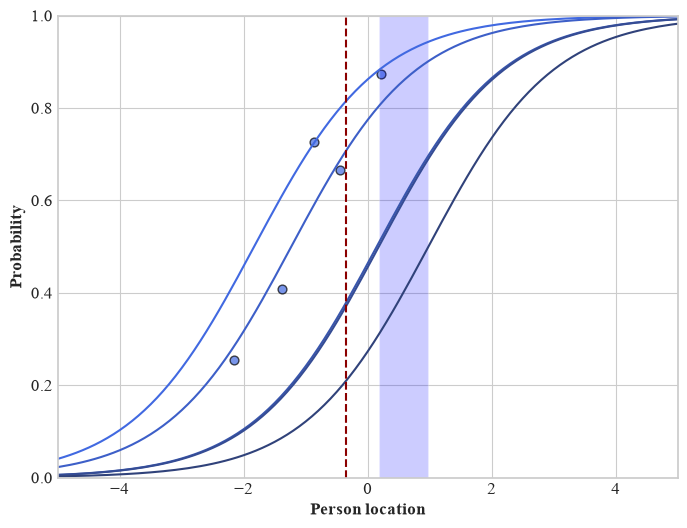

In [29]:
pcm.threshold_ccs('Item_2', central_location=True, obs=[2], cat_highlight=4, xmin=-5, xmax=5, filename='my_pcm_threshold_ccs')

Produce an item information function curve for Item 2

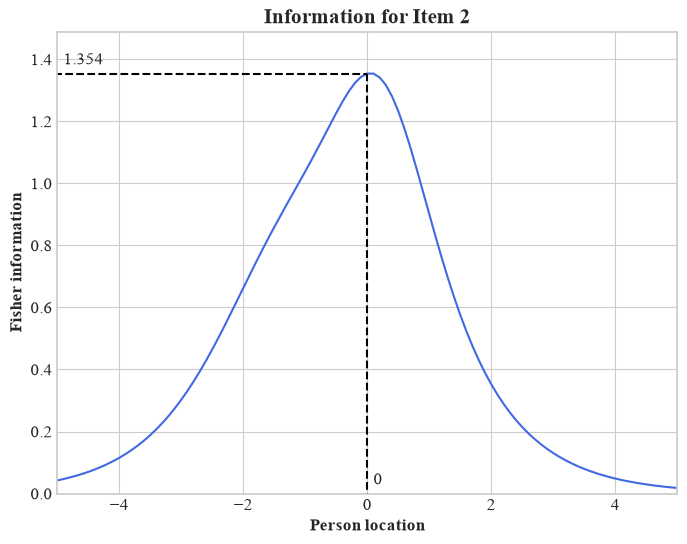

In [30]:
pcm.iic('Item_2', point_info_lines=[0], point_info_labels=True, title='Information for Item 2', xmin=-5, xmax=5, filename='my_pcm_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 15 and 25 plotted.

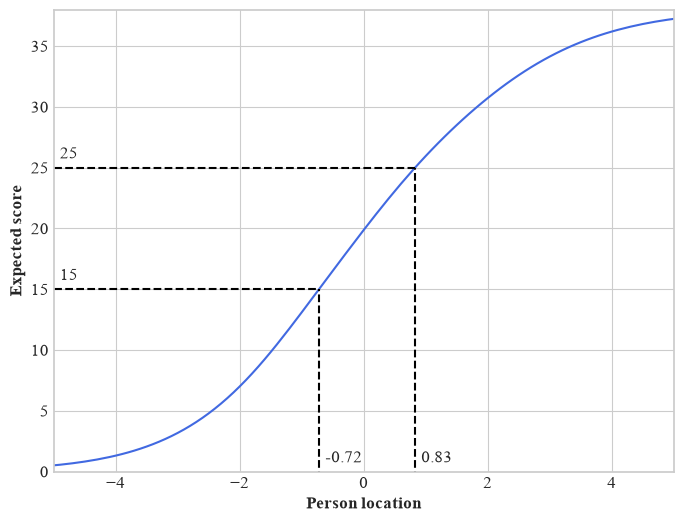

In [31]:
pcm.tcc(score_lines=[15, 25], score_labels=True, filename='my_pcm_tcc')

Produce a test information curve

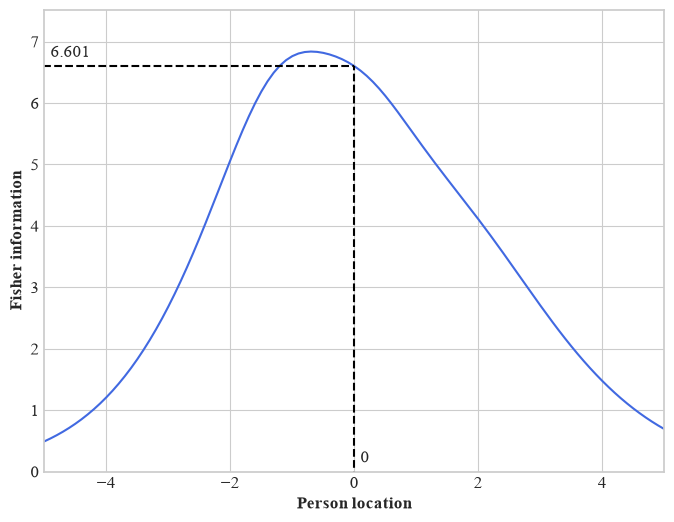

In [32]:
pcm.test_info(point_info_lines=[0], point_info_labels=True, filename='my_pcm_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

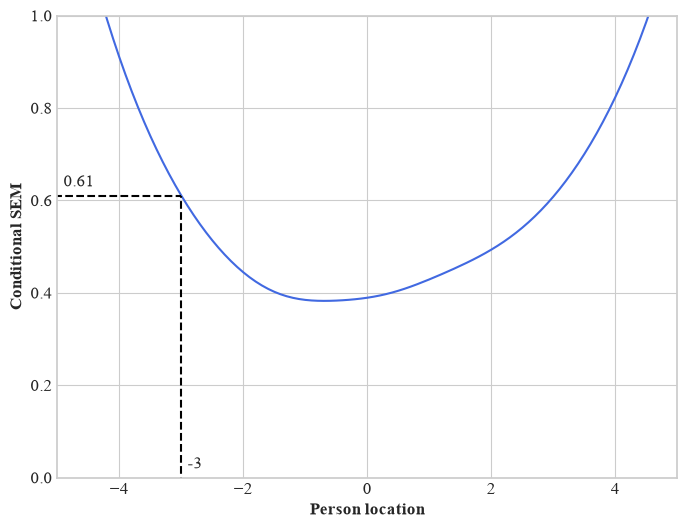

In [33]:
pcm.test_csem(point_csem_lines=[-3], point_csem_labels=True, ymax=1, filename='my_pcm_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

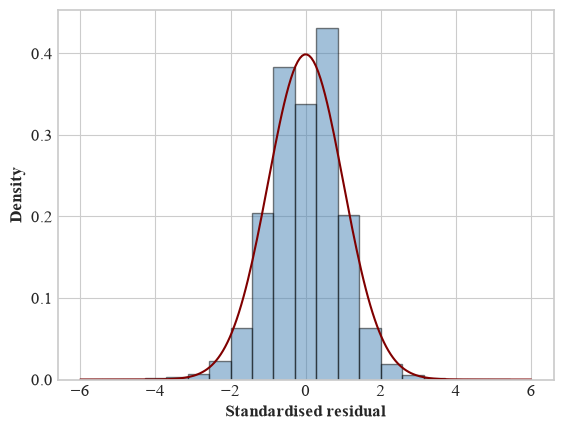

In [34]:
pcm.std_residuals_plot(bin_width=0.6, normal=True, filename='my_pcm_std_residuals_plot')